In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel("Mall_Customers.xlsx")

df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [3]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
# Fill numeric columns with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [6]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame (clean view)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [8]:
# Selecting only important features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]

X.head()

,Annual Income (k$),Spending Score (1-100),Age
0,15,39,19
1,15,81,21
2,16,6,20
3,16,77,23
4,17,40,31


In [9]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [11]:
wcss = []

# Try cluster values from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

c:\Users\bsvar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\bsvar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\bsvar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\bsvar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

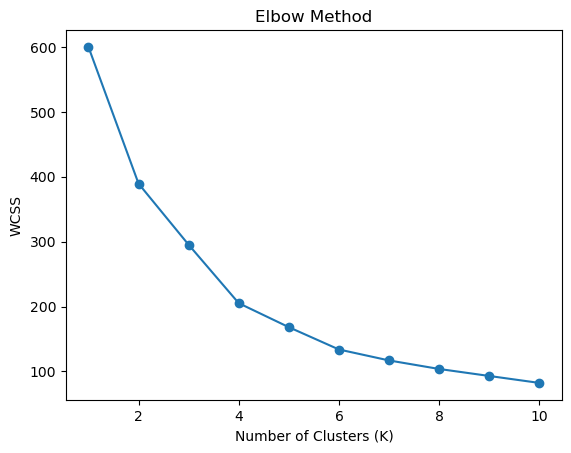

In [12]:
plt.figure()

plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

In [13]:
from sklearn.cluster import KMeans

# Apply KMeans with optimal K = 5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit and predict clusters
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

c:\Users\bsvar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster
0,1,NaN,19,High School,Married,15,39,1
1,2,NaN,21,Graduate,Single,15,81,1
2,3,NaN,20,Graduate,Married,16,6,0
3,4,NaN,23,High School,Unknown,16,77,1
4,5,NaN,31,Uneducated,Married,17,40,1


In [14]:
df['Cluster'].value_counts()

Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64

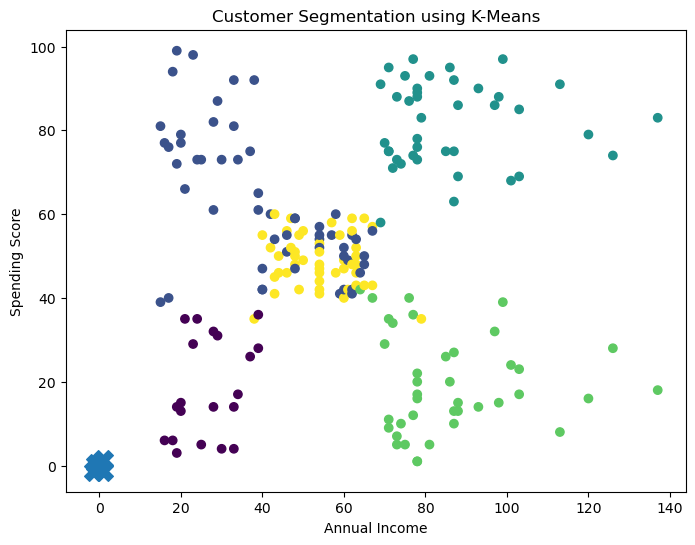

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

# Plot centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 1],  # Income index
    centroids[:, 2],  # Spending index
    s=200,
    marker='X'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [16]:
X = ['Age', 'Annual Income', 'Spending Score']

In [17]:
centroids[:, 1]
centroids[:, 2]

array([-1.23646671,  0.46744035,  1.21608539, -1.19729675, -0.05236781])

In [18]:
from sklearn.cluster import KMeans

# Initialize model (use optimal K = 5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Train the model
kmeans.fit(X_scaled)

c:\Users\bsvar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [19]:
# Predict cluster for each customer
clusters = kmeans.predict(X_scaled)

# Add to dataset
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster
0,1,NaN,19,High School,Married,15,39,1
1,2,NaN,21,Graduate,Single,15,81,1
2,3,NaN,20,Graduate,Married,16,6,0
3,4,NaN,23,High School,Unknown,16,77,1
4,5,NaN,31,Uneducated,Married,17,40,1


In [20]:
# Centroids of clusters
print(kmeans.cluster_centers_)

[[ 0.5310735  -1.2905084  -1.23646671]
 [-0.98067852 -0.74305983  0.46744035]
 [-0.42880597  0.97484722  1.21608539]
 [ 0.07333084  0.97494509 -1.19729675]
 [ 1.20484056 -0.23577338 -0.05236781]]


In [21]:
df[['CustomerID', 'Cluster']].head(10)

,CustomerID,Cluster
0,1,1
1,2,1
2,3,0
3,4,1
4,5,1
5,6,1
6,7,0
7,8,1
8,9,0
9,10,1


In [22]:
df['Cluster'] = kmeans.fit_predict(X_scaled)

c:\Users\bsvar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [23]:
df.to_excel("clustered_customers.xlsx", index=False)

In [24]:
cluster_names = {
    0: "High Spender",
    1: "Low Spender",
    2: "Average",
    3: "Premium",
    4: "Budget"
}

df['Category'] = df['Cluster'].map(cluster_names)

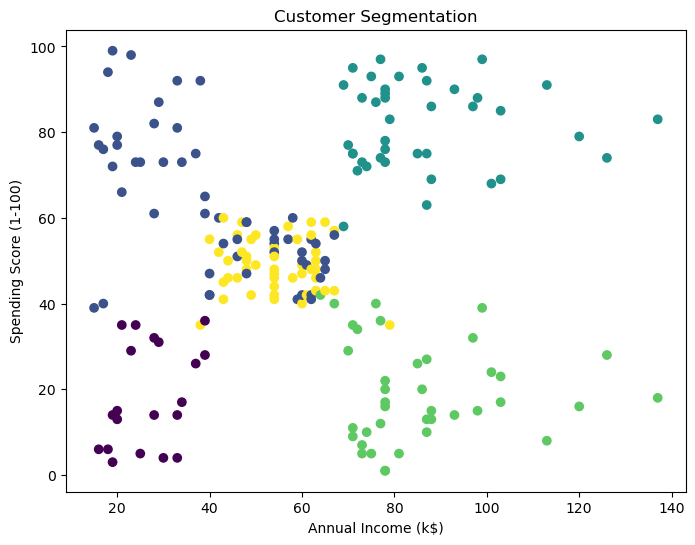

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation")

plt.show()

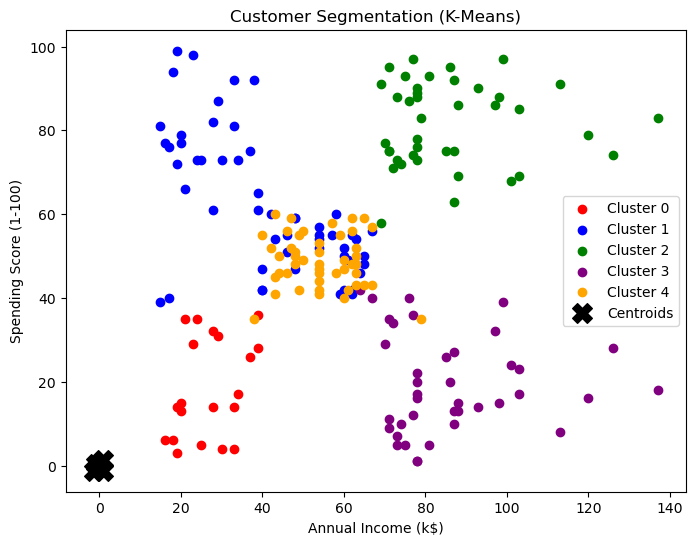

In [26]:
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(5):
    plt.scatter(
        df[df['Cluster'] == i]['Annual Income (k$)'],
        df[df['Cluster'] == i]['Spending Score (1-100)'],
        label=f'Cluster {i}',
        color=colors[i]
    )

# Plot centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 1],   # Income
    centroids[:, 2],   # Spending
    s=200,
    color='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation (K-Means)")
plt.legend()

plt.show()

In [27]:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

In [28]:
centroids[:, 1]
centroids[:, 2]

array([-1.23646671,  0.46744035,  1.21608539, -1.19729675, -0.05236781])

In [30]:
import pickle

# Save trained KMeans model
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Save scaler (very important)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [31]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

In [32]:
import pickle

# Load model
with open("kmeans_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load scaler
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)